<a href="https://colab.research.google.com/github/awildt01/deep-learning-lung-cancer-detection/blob/main/pytorch_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import numpy
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
tensor = torch.tensor([[1,2,3],[4,5,6],[7,8,9]])

In [3]:
tensor

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [4]:
d1 = tensor[:,1]
print(d1)

tensor([2, 5, 8])


In [5]:
d1[:]

tensor([2, 5, 8])

In [22]:
distances = torch.tensor([[1.0],[2.0],[3.0],[4.0]], dtype=torch.float32)

In [23]:
times = torch.tensor([[6.96],[12.11],[16.77],[22.21]],dtype=torch.float32)


- nn.Sequential: Dies ist ein Container in PyTorch, der Module in der Reihenfolge, in der sie hinzugefügt wurden, ausführt. Stell es dir wie eine Kette von Operationen vor. Wenn du Daten durch ein nn.Sequential-Modul schickst, durchlaufen sie nacheinander jedes Modul in der Kette. In diesem Fall enthält es nur ein einziges nn.Linear-Modul.

- nn.Linear(1,1): Dies ist ein Modul, das eine lineare Transformation auf die eingehenden Daten anwendet, also eine Operation der Form y = Ax + b. Die beiden 1er in den Klammern bedeuten folgendes:

    - Der erste 1 steht für die Anzahl der Eingangs-Features (in diesem Fall ist es 1, da wir nur eine "Distanz" als Eingabe haben).
    - Der zweite 1 steht für die Anzahl der Ausgangs-Features (auch hier ist es 1, da wir nur eine "Zeit" vorhersagen möchten).
Dieses nn.Linear-Modul lernt im Training automatisch zwei Parameter: eine Gewichtsmatrix (weight) und einen Bias-Vektor (bias). Diese Parameter werden so angepasst, dass die Vorhersagen des Modells möglichst nah an den tatsächlichen Werten liegen.

In [25]:
# nn.Sequential: Dies ist ein Container, der Module in der Reihenfolge ausführt, in der sie hinzugefügt wurden.
# Es ist wie eine Kette von Operationen.
# nn.Linear(1,1): Dies ist ein Modul, das eine lineare Transformation anwendet (y = Ax + b).
# Der erste '1' steht für die Anzahl der Eingangs-Features (hier 1 für 'Distanz').
# Der zweite '1' steht für die Anzahl der Ausgangs-Features (hier 1 für 'Zeit').
# Dieses Modul lernt eine Gewichtsmatrix und einen Bias-Vektor.
model= nn.Sequential(nn.Linear(1,1))

- loss_function = nn.MSELoss():

  - nn.MSELoss() steht für "Mean Squared Error Loss" (mittlerer quadratischer Fehler). Dies ist eine sehr häufig verwendete Verlustfunktion (Loss Function) in der Regression.
  - Was macht sie? Sie berechnet den durchschnittlichen quadrierten Unterschied zwischen den Vorhersagen deines Modells (outputs) und den tatsächlichen Werten (times).
  - Warum quadriert? Das Quadrieren hat zwei Hauptgründe:
     1. Es bestraft größere Fehler stärker. Ein Fehler von 2 wird viermal so stark bestraft wie ein Fehler von 1.
     2. Es sorgt dafür, dass positive und negative Fehler gleich behandelt werden (z.B. eine Vorhersage von +2 zu hoch ist genauso schlimm wie -2 zu niedrig).
- Ziel: Während des Trainings versucht das Modell, diesen Wert (loss) zu minimieren. Ein niedrigerer MSE-Wert bedeutet, dass die Vorhersagen des Modells näher an den tatsächlichen Werten liegen.

<br>

- optimizer = optim.SGD(model.parameters(), lr=0.01):

    - optimizer: Ein Optimierer ist der "Motor" des Lernprozesses. Seine Aufgabe ist es, die Parameter deines Modells (die Gewichte und Biases, die nn.Linear lernt) anzupassen, um den von der Verlustfunktion berechneten Fehler zu minimieren.
    - optim.SGD: Dies steht für "Stochastic Gradient Descent" (Stochastischer Gradientenabstieg). SGD ist ein grundlegender und weit verbreiteter Optimierungsalgorithmus.
    - model.parameters(): Dies übergibt alle lernbaren Parameter deines model (also die Gewichte und Biases des nn.Linear-Moduls) an den Optimierer. Der Optimierer weiß dann, welche Werte er anpassen muss.
    - lr=0.01: Das ist die "learning rate" (Lernrate). Sie bestimmt, wie groß die Schritte sind, die der Optimierer unternimmt, um die Parameter des Modells anzupassen.
      - Eine große Lernrate kann dazu führen, dass der Optimierer über das optimale Minimum "hinausschießt" und das Modell nie konvergiert.
      - Eine kleine Lernrate kann dazu führen, dass der Trainingsprozess sehr langsam ist, da die Schritte zu klein sind.
      - 0.01 ist ein häufig verwendeter Startwert für die Lernrate, der oft gut funktioniert.
Zusammenfassend lässt sich sagen, dass diese beiden Zeilen das "Wie" des Lernens definieren: Der loss_function sagt dem Modell, wie gut oder schlecht es ist, und der optimizer nutzt diese Information zusammen mit der learning rate, um das Modell Schritt für Schritt besser zu machen.

In [16]:
# define the loss function unda optmizer
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

### Trainingsschleife (Training Loop)

Diese Schleife ist das Herzstück des maschinellen Lernens, denn hier lernt das Modell wirklich aus den Daten. Sie wiederholt den Optimierungsprozess für eine bestimmte Anzahl von 'Epochen'. Eine Epoche bedeutet, dass das Modell einmal den gesamten Trainingsdatensatz gesehen und verarbeitet hat.

Jeder Schritt innerhalb der Schleife folgt einem standardisierten Muster:

1.  **`optimizer.zero_grad()`**: Bevor die Parameter im aktuellen Schritt angepasst werden, müssen die Gradienten (Ableitungen) der vorherigen Trainingsschritte auf Null zurückgesetzt werden. PyTorch sammelt Gradienten standardmäßig an. Wenn dies nicht aufgerufen wird, würden die neuen Gradienten zu den alten hinzugefügt, was zu falschen Updates führen würde.

2.  **`outputs = model(distances)`** (Forward Pass): Die Eingabedaten (`distances`) werden durch das Modell (`model`) geschickt. Das Modell berechnet basierend auf seinen aktuellen Parametern (`weight` und `bias`) die Vorhersagen (`outputs`).

3.  **`loss = loss_function(outputs, times)`**: Die Verlustfunktion (`nn.MSELoss()`) wird aufgerufen. Sie vergleicht die vom Modell gemachten Vorhersagen (`outputs`) mit den tatsächlichen Werten (`times`) und berechnet, wie 'falsch' die Vorhersagen sind. Das Ergebnis ist ein einziger `loss`-Wert, den wir minimieren wollen.

4.  **`loss.backward()`** (Backward Pass / Backpropagation): PyTorch berechnet hier automatisch die Gradienten des `loss`-Wertes in Bezug auf alle lernbaren Parameter des Modells. Diese Gradienten geben an, in welche Richtung und wie stark jeder Parameter angepasst werden muss, um den Verlust zu reduzieren.

5.  **`optimizer.step()`**: Der Optimierer (`optim.SGD`) verwendet die im `backward()`-Schritt berechneten Gradienten, um die Modellparameter (`weight` und `bias`) zu aktualisieren. Er passt die Parameter in die Richtung an, die den Verlust minimiert, und berücksichtigt dabei die `learning rate` (`lr`).

6.  **`if (epoch + 1) % 50 == 0:`**: Dieser Teil ist nur dazu da, den Trainingsfortschritt zu überwachen. Er prüft, ob die aktuelle Epoche ein Vielfaches von 50 ist und gibt dann den aktuellen `loss`-Wert aus. `loss.item()` wird verwendet, um den Python-Standardwert aus dem PyTorch-Tensor zu extrahieren.

In [17]:
# Training loop
for epoch in range(500):
    # Reset the optimizer's gradients
    optimizer.zero_grad()
    # Make predictions (forward pass)
    outputs = model(distances)
    # Calculate the loss
    loss = loss_function(outputs, times)
    # Calculate adjustments (backward pass)
    loss.backward()
    # Update the model's parameters
    optimizer.step()
    # Print loss every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}: Loss = {loss.item()}")

Epoch 50: Loss = 0.050111766904592514
Epoch 100: Loss = 0.043711304664611816
Epoch 150: Loss = 0.03897202014923096
Epoch 200: Loss = 0.03546051308512688
Epoch 250: Loss = 0.03285869583487511
Epoch 300: Loss = 0.030930954962968826
Epoch 350: Loss = 0.029502512887120247
Epoch 400: Loss = 0.028444333001971245
Epoch 450: Loss = 0.027660179883241653
Epoch 500: Loss = 0.027079109102487564


In [20]:
import matplotlib.pyplot as plt

def plot_results(model, distances, times):
    plt.scatter(distances.numpy(), times.numpy(), label='Original Data')
    with torch.no_grad():
        predicted_times = model(distances)
    plt.plot(distances.numpy(), predicted_times.numpy(), color='red', label='Model Predictions')
    plt.xlabel('Distances')
    plt.ylabel('Times')
    plt.title('Model Predictions vs Original Data')
    plt.legend()
    plt.grid(True)
    plt.show()

- Blaue Punkte (Originaldaten): Diese repräsentieren die ursprünglichen Datenpunkte, die Sie dem Modell zur Verfügung gestellt haben (Entfernungen und entsprechende Zeiten).

- Rote Linie (Modellvorhersagen): Dies ist die Linie, die unser lineares Modell (ein einfacher nn.Linear(1,1) von PyTorch) gelernt hat. Sie zeigt die Zeiten an, die das Modell für die gegebenen Entfernungen vorhersagt.
Interpretation:

Man kann sehen, dass die rote Linie (Modellvorhersagen) sehr nah an den blauen Punkten (Originaldaten) liegt. Dies deutet darauf hin, dass das Modell eine gute Arbeit geleistet hat, um die Beziehung zwischen den Entfernungen und den Zeiten zu lernen. Die Trainingsschleife mit 500 Epochen und der MSELoss (Mean Squared Error Loss) hat dazu geführt, dass das Modell eine Linie gefunden hat, die den Abstand zwischen den Vorhersagen und den tatsächlichen Werten minimiert hat. Der angezeigte Loss von 0.027079109102487564 nach 500 Epochen bestätigt, dass das Modell eine geringe Fehlerquote auf den Trainingsdaten erzielt hat.

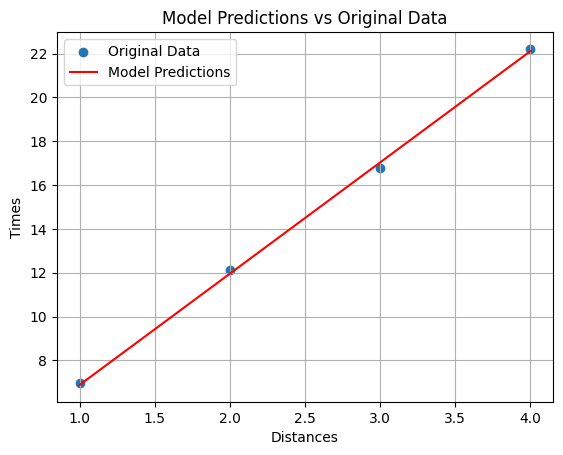

In [21]:
plot_results(model, distances, times)

In [26]:
distance_to_predict = 7.0

In [27]:
# Use the torch.no_grad() context manager for efficient predictions
with torch.no_grad():
    # Convert the Python variable into a 2D PyTorch tensor that the model expects
    new_distance = torch.tensor([[distance_to_predict]], dtype=torch.float32)

    # Pass the new data to the trained model to get a prediction
    predicted_time = model(new_distance)

    # Use .item() to extract the scalar value from the tensor for printing
    print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time.item():.1f} minutes")

    # Use the scalar value in a conditional statement to make the final decision
    if predicted_time.item() > 30:
        print("\nDecision: Do NOT take the job. You will likely be late.")
    else:
        print("\nDecision: Take the job. You can make it!")

Prediction for a 7.0-mile delivery: 3.8 minutes

Decision: Take the job. You can make it!


In [28]:
# Access the first (and only) layer in the sequential model
layer = model[0]

# Get weights and bias
weights = layer.weight.data.numpy()
bias = layer.bias.data.numpy()

print(f"Weight: {weights}")
print(f"Bias: {bias}")

Weight: [[0.64989555]]
Bias: [-0.7555394]
